In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ANALIZA PODATKOV O OGLASIH ZA PRODAJO PAMETNIH TELEFONOV NA BOLHA.COM
Uvod v programiranje, seminarska naloga, 17. 8. 2026
Tina Dujc

V nadaljevanju sledi analiza podatkov o oglasih za prodajo rabljenih in novih pametnih telefonov, ki so bili v času zajema objavljeni na spletnem oglasniku Bolha.com, v kategoriji Pametni mobilni telefoni. Podatki so bili pridobljeni s spletne strani https://www.bolha.com/pametni-mobilni-telefoni.

PODATKI:
Podatki so javno dostopni vsem obiskovalcem strani, brez potrebne prijave. S pomočjo knjižnic requests in BeautifulSoup sem najprej prenesla HTML vsebino 35 strani z oglasi, nato pa sem iz nje izluščila podatke o posameznih oglasih in jih shranila v datoteki podatki_telefonov.csv in podatki_telefonov.json. Pri urejanju sem izločila oglase, kjer nekdo telefon išče oz. odkupuje (ti niso prave prodajne ponudbe), ter podvojene, izpostavljene oglase. Podatki, ki jih vsebujeta datoteki, so naslednji:

NASLOV OGLASA:
Naslov, ki ga je prodajalec vnesel za svoj oglas.

ZNAMKA:
Znamka telefona, ki sem jo iz naslova oglasa določila glede na ključne besede (npr. iPhone -> Apple, Redmi -> Xiaomi). Če iz naslova znamke ni bilo mogoče razbrati, sem oglas označila kot "Drugo".

KAPACITETA (GB):
Shranjevalna kapaciteta telefona v GB, prav tako izluščena iz naslova oglasa. Pri nekaterih oglasih ta podatek v naslovu ni naveden.

CENA:
Cena telefona v evrih. Oglase, kjer je namesto cene navedeno "Cena po dogovoru", sem pri cenovnih analizah izpustila.

KRAJ:
Kraj, kjer prodajalec ponuja telefon.

DATUM OBJAVE:
Datum, ko je bil oglas objavljen na strani.

V nadaljevanju sem podatke poizkušala analizirati na čim bolj zanimiv način in ugotovitve prikazati s pomočjo tabel in vizualizacij.

1. PORAZDELITEV CEN NA TRGU

Najprej me je zanimalo, kakšne cene v splošnem lahko pričakujemo na trgu rabljenih in novih pametnih telefonov. Analiza temelji na 695 oglasih, ki imajo navedeno konkretno ceno. Povprečna cena telefona znaša 693,68 €, mediana pa je nekoliko nižja, 649,50 €, kar pomeni, da nekaj dražjih telefonov povprečje nekoliko dviguje. Najcenejši telefon je bilo mogoče kupiti za 15 €, najdražji pa je stal kar 2.249,98 €. Standardni odklon v višini 446,30 € kaže na precejšnjo razpršenost cen, kar je pričakovano, saj so med oglasi tako stari, poškodovani telefoni kot tudi popolnoma novi, še zapakirani vrhunski modeli.

OSNOVNE UGOTOVITVE:
Število oglasov s ceno: 695
Povprečna cena: 693.68€
Mediana cene: 649.50€
Minimalna cena: 15.00€
Maksimalna cena: 2249.98€
Standardni odklon: 446.30€


/var/folders/12/22v5mzx95_q9hsytg6hbm1840000gn/T/ipykernel_19661/2738945903.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_s_ceno['Cena'], vert=False)


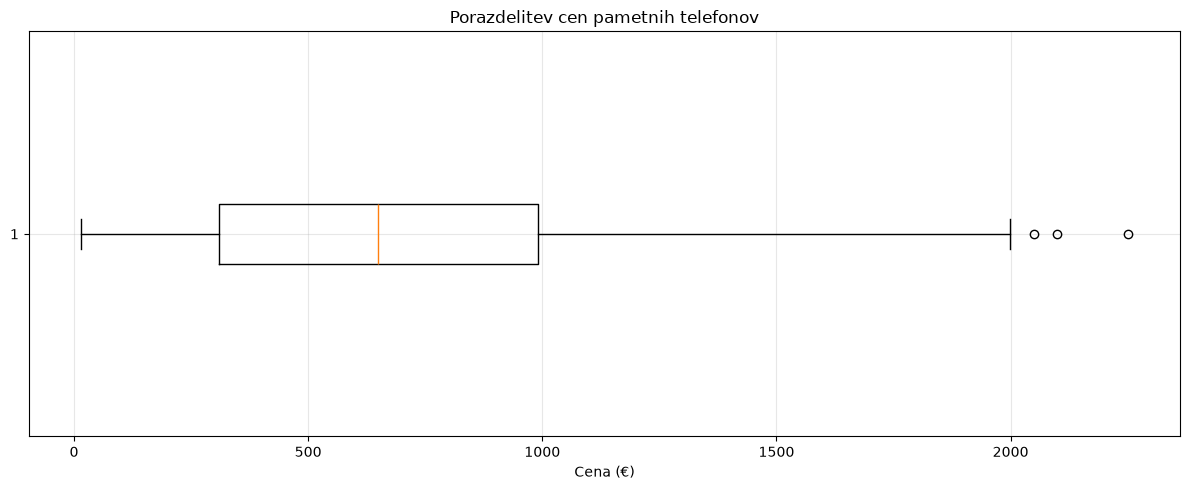

In [2]:
df = pd.read_csv('podatki_telefonov.csv')
df_s_ceno = df[df['Cena'].notna()]

print("OSNOVNE UGOTOVITVE:")
print(f"Število oglasov s ceno: {len(df_s_ceno)}")
print(f"Povprečna cena: {df_s_ceno['Cena'].mean():.2f}€")
print(f"Mediana cene: {df_s_ceno['Cena'].median():.2f}€")
print(f"Minimalna cena: {df_s_ceno['Cena'].min():.2f}€")
print(f"Maksimalna cena: {df_s_ceno['Cena'].max():.2f}€")
print(f"Standardni odklon: {df_s_ceno['Cena'].std():.2f}€")

plt.figure(figsize=(12, 5))
plt.boxplot(df_s_ceno['Cena'], vert=False)
plt.xlabel('Cena (€)')
plt.title('Porazdelitev cen pametnih telefonov')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2. KATERE ZNAMKE PREVLADUJEJO NA TRGU?

Zanimalo me je tudi, katere znamke telefonov se med oglasi pojavljajo najpogosteje. Pričakovala sem, da bosta prevladovala Samsung in Apple, kar se je tudi izkazalo za točno. Samsung se pojavi v 41,3 % oglasov, Apple pa mu tesno sledi z 40,1 %. Na tretjem mestu je Xiaomi z 8,8 %, vse ostale znamke (Honor, OnePlus, Google, Realme, Oppo, Huawei, Motorola, Vivo, Nokia) pa so skupaj zastopane v manj kot 10 % oglasov.

Znamka
Samsung     291
Apple       283
Xiaomi       62
Drugo        24
Honor        17
OnePlus       9
Google        6
Realme        4
Oppo          3
Huawei        2
Motorola      2
Vivo          1
Nokia         1
Name: count, dtype: int64


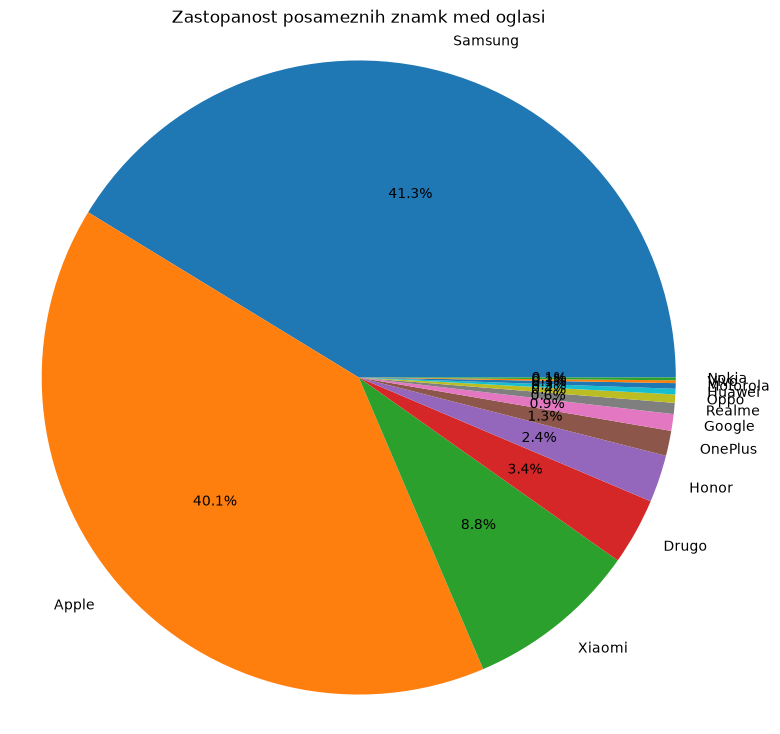

In [3]:
stevilo_po_znamki = df['Znamka'].value_counts()
print(stevilo_po_znamki)

plt.figure(figsize=(9, 9))
plt.pie(stevilo_po_znamki.values, labels=stevilo_po_znamki.index, autopct='%1.1f%%')
plt.title('Zastopanost posameznih znamk med oglasi')
plt.axis('equal')
plt.show()

3. KATERA ZNAMKA JE V POVPREČJU NAJDRAŽJA?

Ker sta Samsung in Apple na trgu približno enako zastopana, me je zanimalo, katera od znamk je v povprečju dražja. V nadaljnjo primerjavo sem vključila le znamke z vsaj 5 oglasi, da so povprečja bolj zanesljiva. Izkazalo se je, da je v povprečju najdražja znamka Apple s povprečno ceno 832,04 €, tik za njim pa je Samsung s povprečno ceno 709,64 €. Sledita Google in Honor, najcenejši pa so med bolj zastopanimi znamkami telefoni znamke Xiaomi, kar je pričakovano, saj gre pri tej znamki predvsem za cenovno dostopnejše modele.

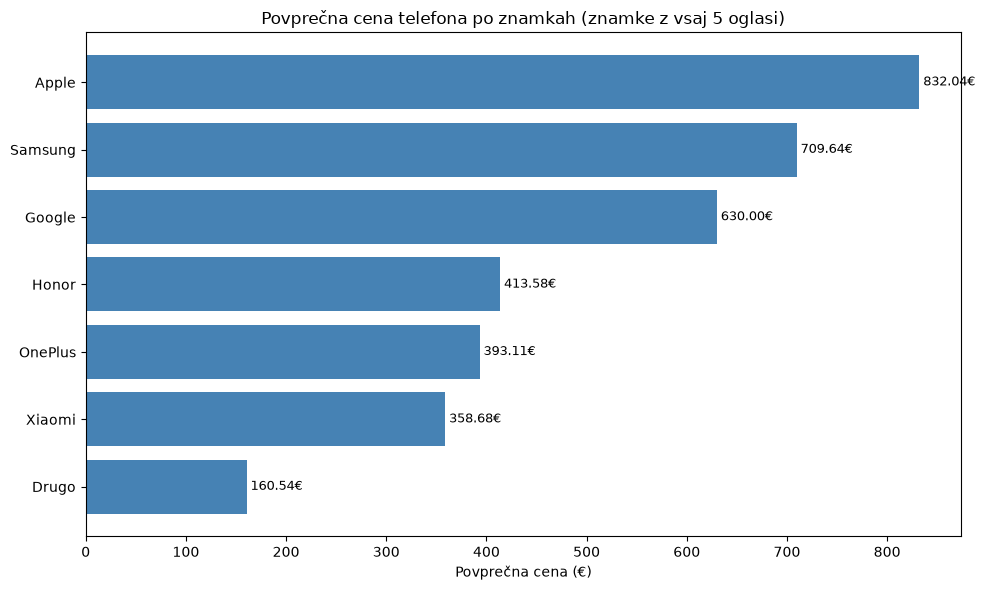

In [4]:
povprecna_cena_po_znamki = df.groupby('Znamka').agg(povprecna_cena=('Cena', 'mean'), stevilo_oglasov=('Cena', 'count'))
povprecna_cena_po_znamki = povprecna_cena_po_znamki[povprecna_cena_po_znamki['stevilo_oglasov'] >= 5]
povprecna_cena_po_znamki = povprecna_cena_po_znamki.sort_values('povprecna_cena', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(povprecna_cena_po_znamki.index, povprecna_cena_po_znamki['povprecna_cena'], color='steelblue')
plt.xlabel('Povprečna cena (€)')
plt.title('Povprečna cena telefona po znamkah (znamke z vsaj 5 oglasi)')
for i, vrednost in enumerate(povprecna_cena_po_znamki['povprecna_cena']):
    plt.text(vrednost, i, f' {vrednost:.2f}€', va='center', fontsize=9)
plt.tight_layout()
plt.show()

4. ALI VEČ POMNILNIKA POMENI VIŠJO CENO?

V tem delu me je zanimalo, ali obstaja povezava med shranjevalno kapaciteto telefona (izraženo v GB) in njegovo ceno. Za merjenje povezanosti sem uporabila Pearsonov korelacijski koeficient, rezultate pa sem prikazala s scatter plotom in regresijsko premico. Analiza, ki temelji na 556 oglasih z znano kapaciteto in ceno, je pokazala zmerno pozitivno korelacijo (Pearsonov koeficient: 0,525). To pomeni, da telefoni z več prostora v splošnem res dosegajo višje cene, vendar povezava ni izjemno močna, kar je smiselno, saj na ceno poleg kapacitete vpliva še veliko drugih dejavnikov - predvsem model in stanje telefona.

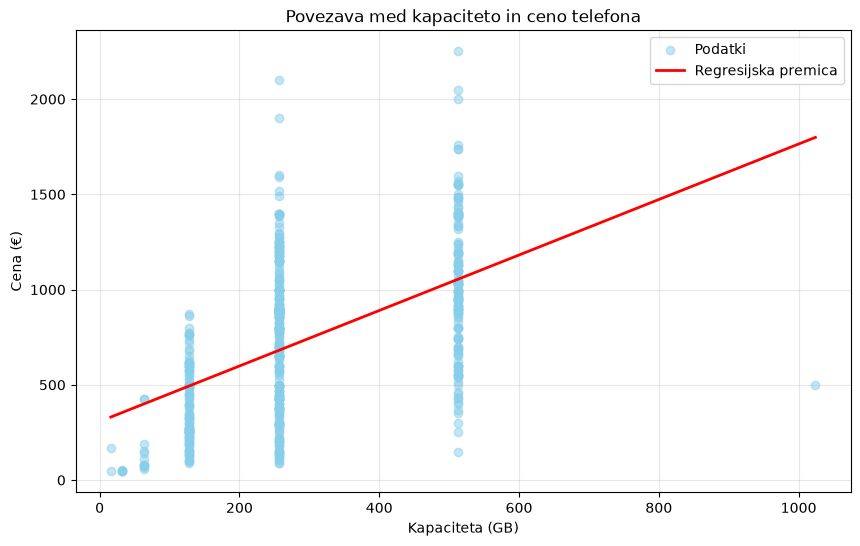

Pearsonov korelacijski koeficient: 0.525


In [5]:
df_kapaciteta = df[df['Cena'].notna() & df['Kapaciteta (GB)'].notna()]

X = df_kapaciteta['Kapaciteta (GB)'].values
y = df_kapaciteta['Cena'].values

pearson = np.corrcoef(X, y)[0, 1]
koeficienti = np.polyfit(X, y, 1)
regresija = np.poly1d(koeficienti)
y_napoved = regresija(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, color='skyblue', label='Podatki')
plt.plot(sorted(X), regresija(sorted(X)), color='red', linewidth=2, label='Regresijska premica')
plt.xlabel('Kapaciteta (GB)')
plt.ylabel('Cena (€)')
plt.title('Povezava med kapaciteto in ceno telefona')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Pearsonov korelacijski koeficient: {pearson:.3f}")

5. KJE JE OGLASOV NAJVEČ IN KAKŠNE SO TAM CENE?

Zanimalo me je tudi, v katerih krajih je oglasov za prodajo telefonov največ in kakšne so tam povprečne cene. Ker je v veliko krajih premalo oglasov za zanesljivo primerjavo, sem se osredotočila na kraje z vsaj 10 oglasi. Največ oglasov prihaja iz Kopra in Laškega, kar verjetno kaže na to, da od tam prodajajo tudi nekateri trgovci oz. odkupovalci telefonov, ki objavijo večje število oglasov naenkrat. Najvišje povprečne cene so dosežene prav v Kopru, sledita pa Spletna ponudba (torej oglasi brez natančne lokacije) in Ljubljana Bežigrad. Najnižje povprečne cene med izbranimi kraji so bile zabeležene v Postojni.

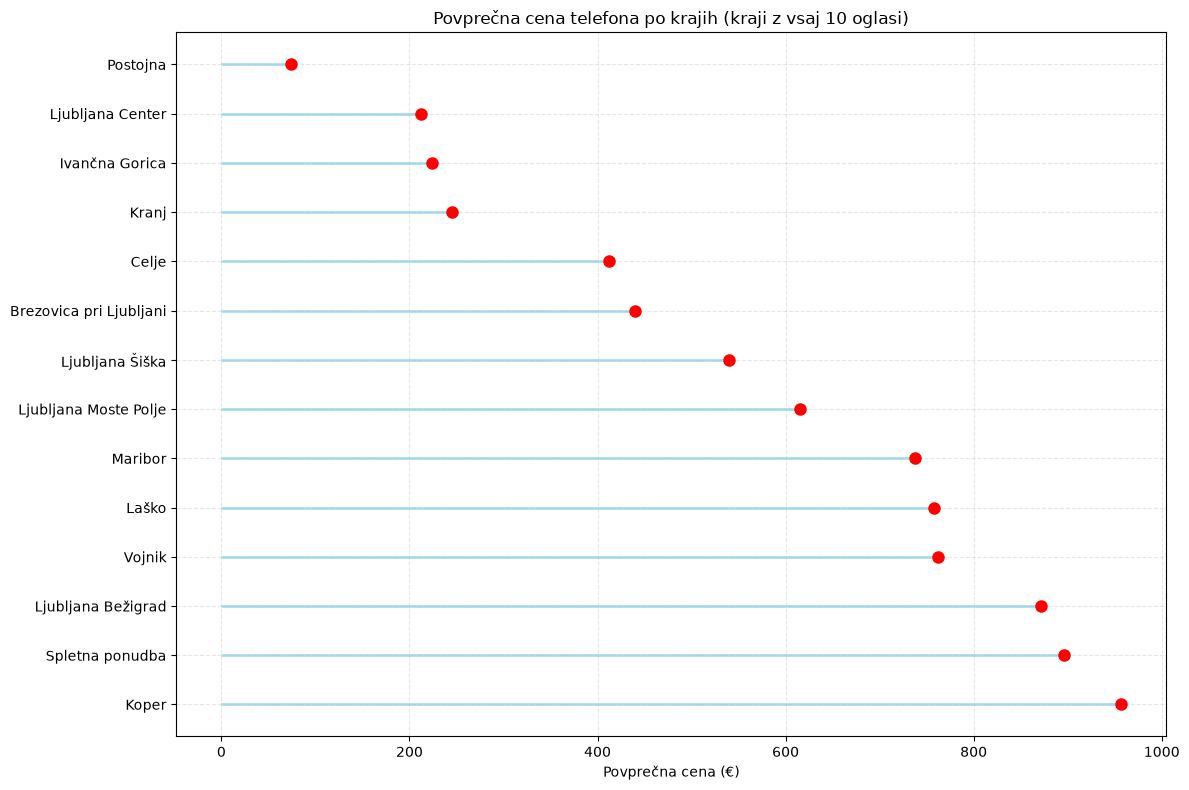

                         stevilo_oglasov  povprecna_cena
Kraj                                                    
Koper                                159          956.70
Spletna ponudba                       17          895.59
Ljubljana Bežigrad                    19          871.93
Vojnik                                45          761.75
Laško                                172          758.04
Maribor                               44          737.71
Ljubljana Moste Polje                 23          615.56
Ljubljana Šiška                       10          540.00
Brezovica pri Ljubljani               28          439.68
Celje                                 22          412.40
Kranj                                 10          245.55
Ivančna Gorica                        21          224.24
Ljubljana Center                      18          212.41
Postojna                              12           73.67


In [6]:
statistika_krajev = df.groupby('Kraj').agg(stevilo_oglasov=('Kraj', 'count'), povprecna_cena=('Cena', 'mean'))
statistika_krajev = statistika_krajev[statistika_krajev['stevilo_oglasov'] >= 10].sort_values('povprecna_cena', ascending=False)

plt.figure(figsize=(12, 8))
plt.hlines(y=statistika_krajev.index, xmin=0, xmax=statistika_krajev['povprecna_cena'], color='skyblue', alpha=0.7, linewidth=2)
plt.plot(statistika_krajev['povprecna_cena'], statistika_krajev.index, "o", markersize=8, color='red')
plt.xlabel('Povprečna cena (€)')
plt.title('Povprečna cena telefona po krajih (kraji z vsaj 10 oglasi)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(statistika_krajev.round(2))

6. APPLE PROTI SAMSUNG - KDO JE V POVPREČJU DRAŽJI?

Ker sta Samsung in Apple daleč najbolj zastopani znamki, sem za konec ti dve znamki še podrobneje primerjala med seboj. Telefoni znamke Apple dosegajo v povprečju višjo ceno (832,04 €) kot telefoni znamke Samsung (709,64 €), podobno razmerje pa velja tudi za mediano (856,00 € pri Applu v primerjavi z 699,00 € pri Samsungu). Iz boxplotov je razvidno tudi, da je pri obeh znamkah razpon cen precej širok, saj so med oglasi tako starejši modeli po nizkih cenah kot tudi najnovejši, še zapakirani telefoni po visokih cenah.

Apple: povprečje = 832.04€, mediana = 856.00€, št. oglasov = 279
Samsung: povprečje = 709.64€, mediana = 699.00€, št. oglasov = 287


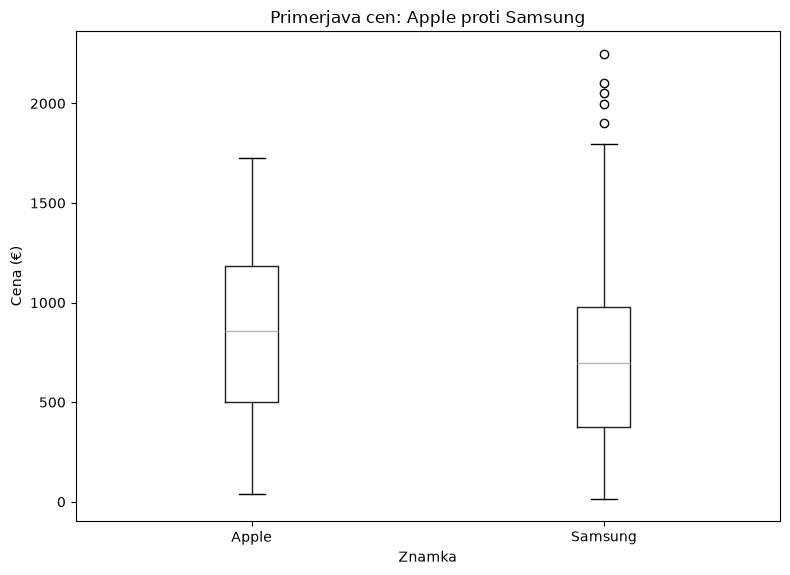

In [7]:
df_primerjava = df[df['Znamka'].isin(['Apple', 'Samsung']) & df['Cena'].notna()]

for znamka in ['Apple', 'Samsung']:
    podatki_znamke = df_primerjava[df_primerjava['Znamka'] == znamka]['Cena']
    print(f"{znamka}: povprečje = {podatki_znamke.mean():.2f}€, mediana = {podatki_znamke.median():.2f}€, št. oglasov = {len(podatki_znamke)}")

df_primerjava.boxplot(column='Cena', by='Znamka', grid=False, figsize=(8, 6))
plt.xlabel('Znamka')
plt.ylabel('Cena (€)')
plt.title('Primerjava cen: Apple proti Samsung')
plt.suptitle('')
plt.tight_layout()
plt.show()

ZAKLJUČEK:

Analiza podatkov o oglasih za prodajo pametnih telefonov na Bolha.com mi je dala precej dober vpogled v to, kako je videti trg rabljenih in novih telefonov v Sloveniji. Ugotovila sem, da na trgu prevladujeta znamki Samsung in Apple, pri čemer so Applovi telefoni v povprečju nekoliko dražji od Samsungovih. Potrdila se je tudi pričakovana povezava med shranjevalno kapaciteto in ceno telefona, čeprav ta povezava ni izjemno močna, kar pomeni, da na ceno poleg kapacitete vpliva še vrsta drugih dejavnikov, ki jih iz samega naslova oglasa ni mogoče razbrati (npr. stanje telefona, model, starost). Z analizo sem se poleg vsega naučila tudi, kako lahko s pomočjo Pythona iz spletne strani pridobim in uredim podatke ter jih nato analiziram in smiselno predstavim.